In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings("ignore")

df = pd.read_csv("train.csv")

In [40]:
pip install pandas numpy matplotlib seaborn scikit-learn jupyter

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [41]:
import pandas as pd

df = pd.read_csv("train.csv")

print(df.shape)
df.head()

(1460, 81)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [43]:
df.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [44]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 1460
Number of columns: 81


In [45]:
missing_values = df.isnull().sum()

missing_values = missing_values[missing_values > 0].sort_values(ascending=False)

print(missing_values)

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtExposure      38
BsmtFinType2      38
BsmtQual          37
BsmtCond          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
dtype: int64


In [46]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [47]:
print(df["SalePrice"].describe())
print("Minimum House Price:", df["SalePrice"].min())
print("Maximum House Price:", df["SalePrice"].max())
print("Average House Price:", df["SalePrice"].mean())


count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64
Minimum House Price: 34900
Maximum House Price: 755000
Average House Price: 180921.19589041095


In [48]:
numerical_columns = df.select_dtypes(include=np.number).columns
categorical_columns = df.select_dtypes(include="object").columns

print("Number of numerical columns:", len(numerical_columns))
print("Number of categorical columns:", len(categorical_columns))

print("\nNumerical columns:")
print(list(numerical_columns))

print("\nCategorical columns:")
print(list(categorical_columns))

Number of numerical columns: 38
Number of categorical columns: 43

Numerical columns:
['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'MoSold', 'YrSold', 'SalePrice']

Categorical columns:
['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC',

In [49]:
missing_percent = (df.isnull().sum() / len(df)) * 100

missing_data = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": missing_percent
})

missing_data = missing_data[missing_data["Missing Values"] > 0]
missing_data = missing_data.sort_values(
    by="Percentage",
    ascending=False
)

missing_data

,Missing Values,Percentage
PoolQC,1453,99.520548
MiscFeature,1406,96.301370
Alley,1369,93.767123
Fence,1179,80.753425
MasVnrType,872,59.726027
FireplaceQu,690,47.260274
LotFrontage,259,17.739726
GarageType,81,5.547945
GarageYrBlt,81,5.547945
GarageFinish,81,5.547945


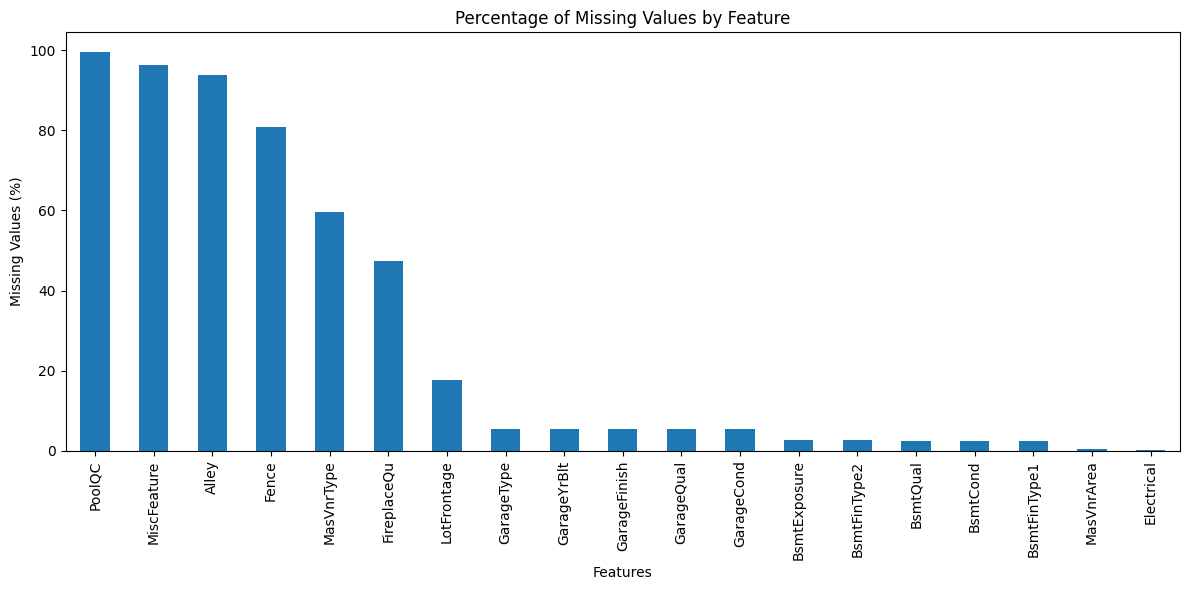

In [50]:
plt.figure(figsize=(12, 6))

missing_data["Percentage"].plot(kind="bar")

plt.title("Percentage of Missing Values by Feature")
plt.xlabel("Features")
plt.ylabel("Missing Values (%)")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [51]:
df_clean = df.copy()

# Separate numerical and categorical columns
numerical_columns = df_clean.select_dtypes(include=np.number).columns
categorical_columns = df_clean.select_dtypes(include="object").columns

# Fill categorical missing values
for col in categorical_columns:
    df_clean[col] = df_clean[col].fillna("None")

# Fill numerical missing values with median
for col in numerical_columns:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

print("Missing values after cleaning:")
print(df_clean.isnull().sum().sum())

Missing values after cleaning:
0


In [52]:
print("Duplicate rows before removal:", df_clean.duplicated().sum())

df_clean = df_clean.drop_duplicates()

print("Dataset shape after cleaning:", df_clean.shape)

Duplicate rows before removal: 0
Dataset shape after cleaning: (1460, 81)


In [53]:
df_clean.head()
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1460 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          1460 non-null   object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

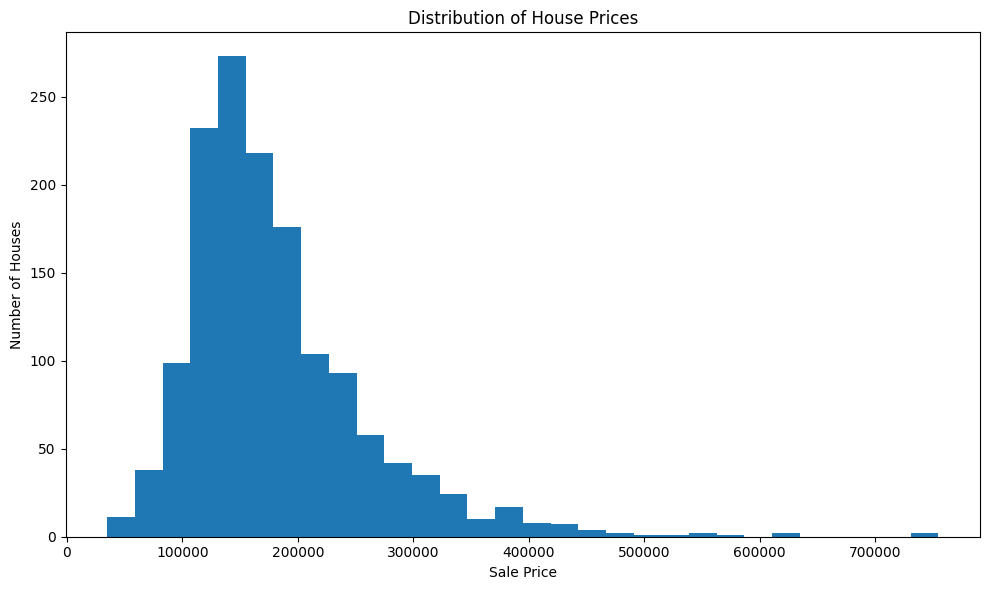

In [54]:
plt.figure(figsize=(10, 6))

plt.hist(df_clean["SalePrice"], bins=30)

plt.title("Distribution of House Prices")
plt.xlabel("Sale Price")
plt.ylabel("Number of Houses")

plt.tight_layout()
plt.show()

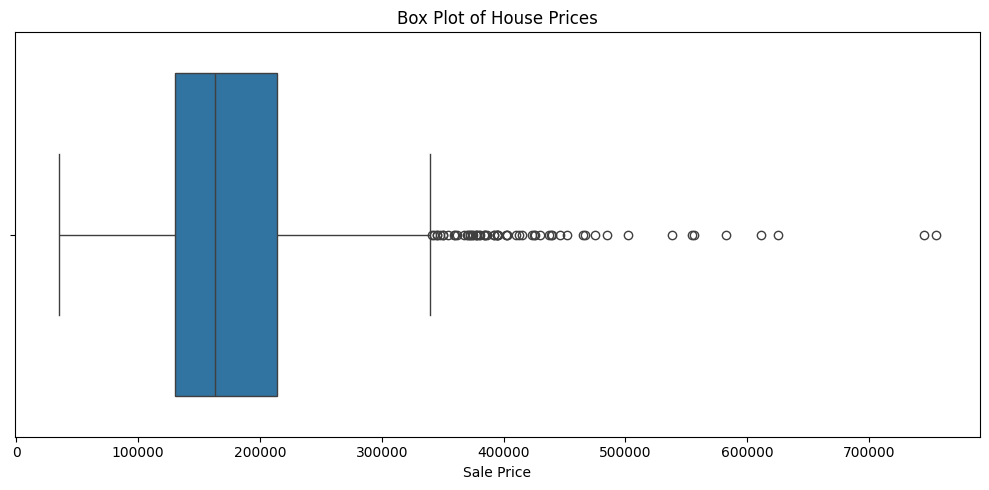

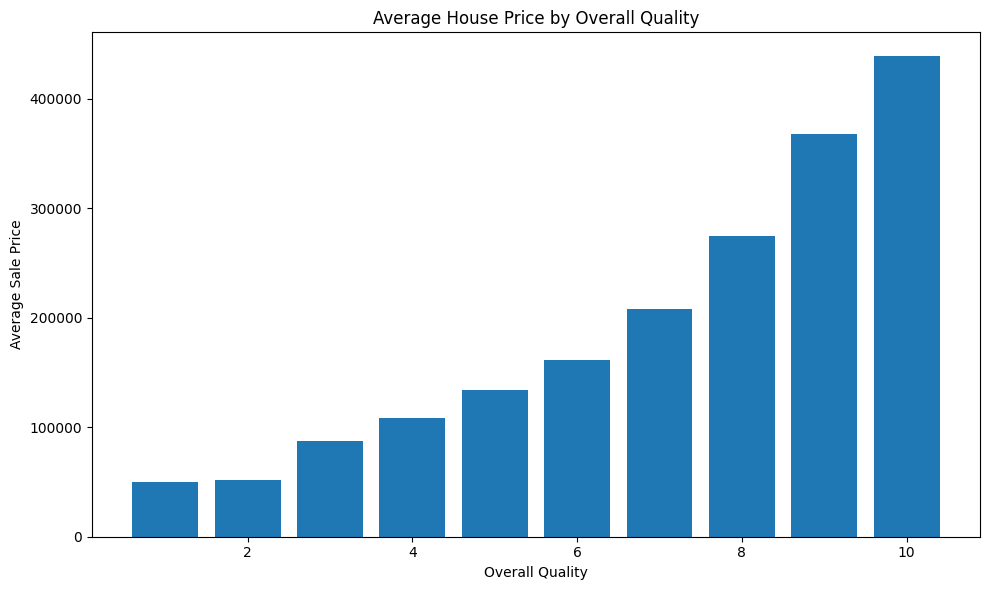

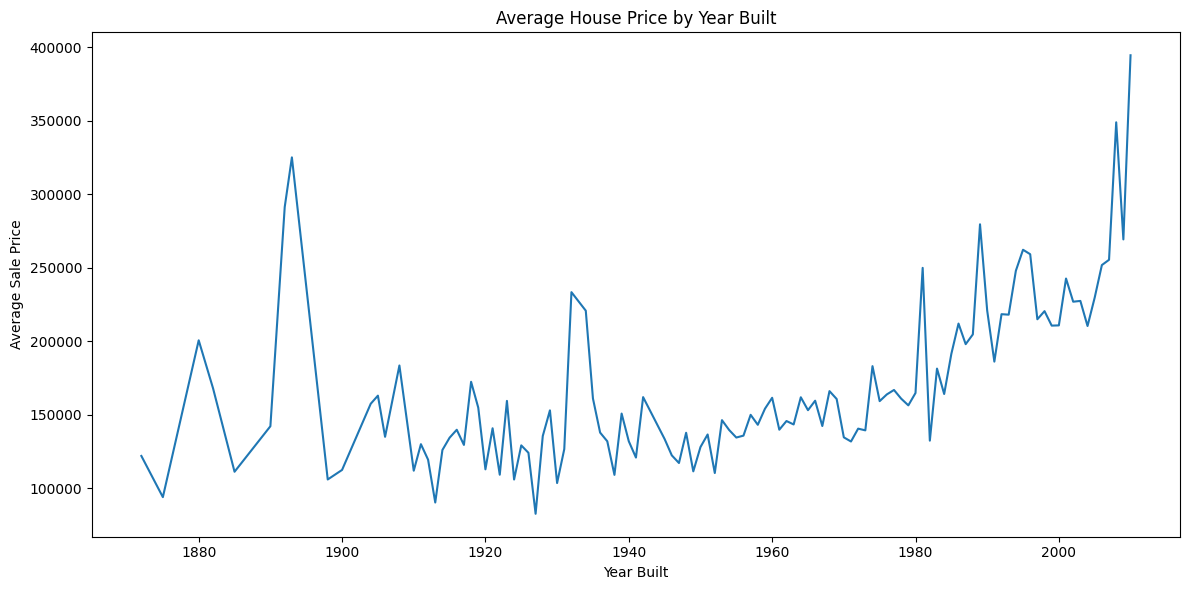

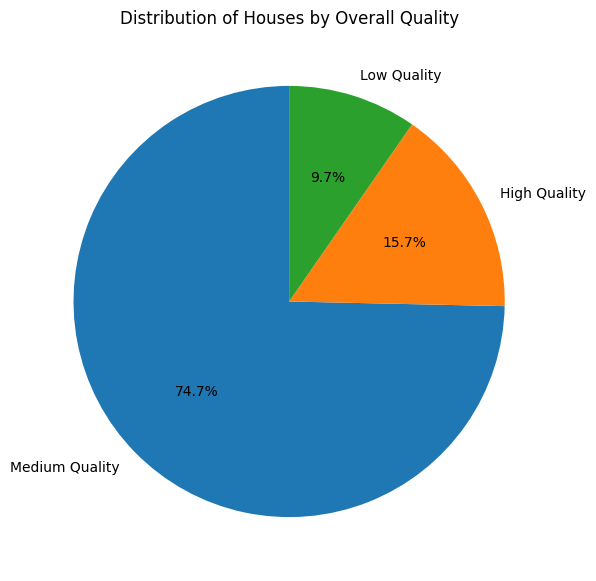

In [55]:
plt.figure(figsize=(10, 5))

sns.boxplot(x=df_clean["SalePrice"])

plt.title("Box Plot of House Prices")
plt.xlabel("Sale Price")

plt.tight_layout()
plt.show()

quality_price = df_clean.groupby("OverallQual")["SalePrice"].mean()

plt.figure(figsize=(10, 6))

plt.bar(quality_price.index, quality_price.values)

plt.title("Average House Price by Overall Quality")
plt.xlabel("Overall Quality")
plt.ylabel("Average Sale Price")

plt.tight_layout()
plt.show()

year_price = df_clean.groupby("YearBuilt")["SalePrice"].mean()

plt.figure(figsize=(12, 6))

plt.plot(year_price.index, year_price.values)

plt.title("Average House Price by Year Built")
plt.xlabel("Year Built")
plt.ylabel("Average Sale Price")

plt.tight_layout()
plt.show()

quality_category = pd.cut(
    df_clean["OverallQual"],
    bins=[0, 4, 7, 10],
    labels=["Low Quality", "Medium Quality", "High Quality"]
)

quality_counts = quality_category.value_counts()

plt.figure(figsize=(7, 7))

plt.pie(
    quality_counts.values,
    labels=quality_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Distribution of Houses by Overall Quality")

plt.show()

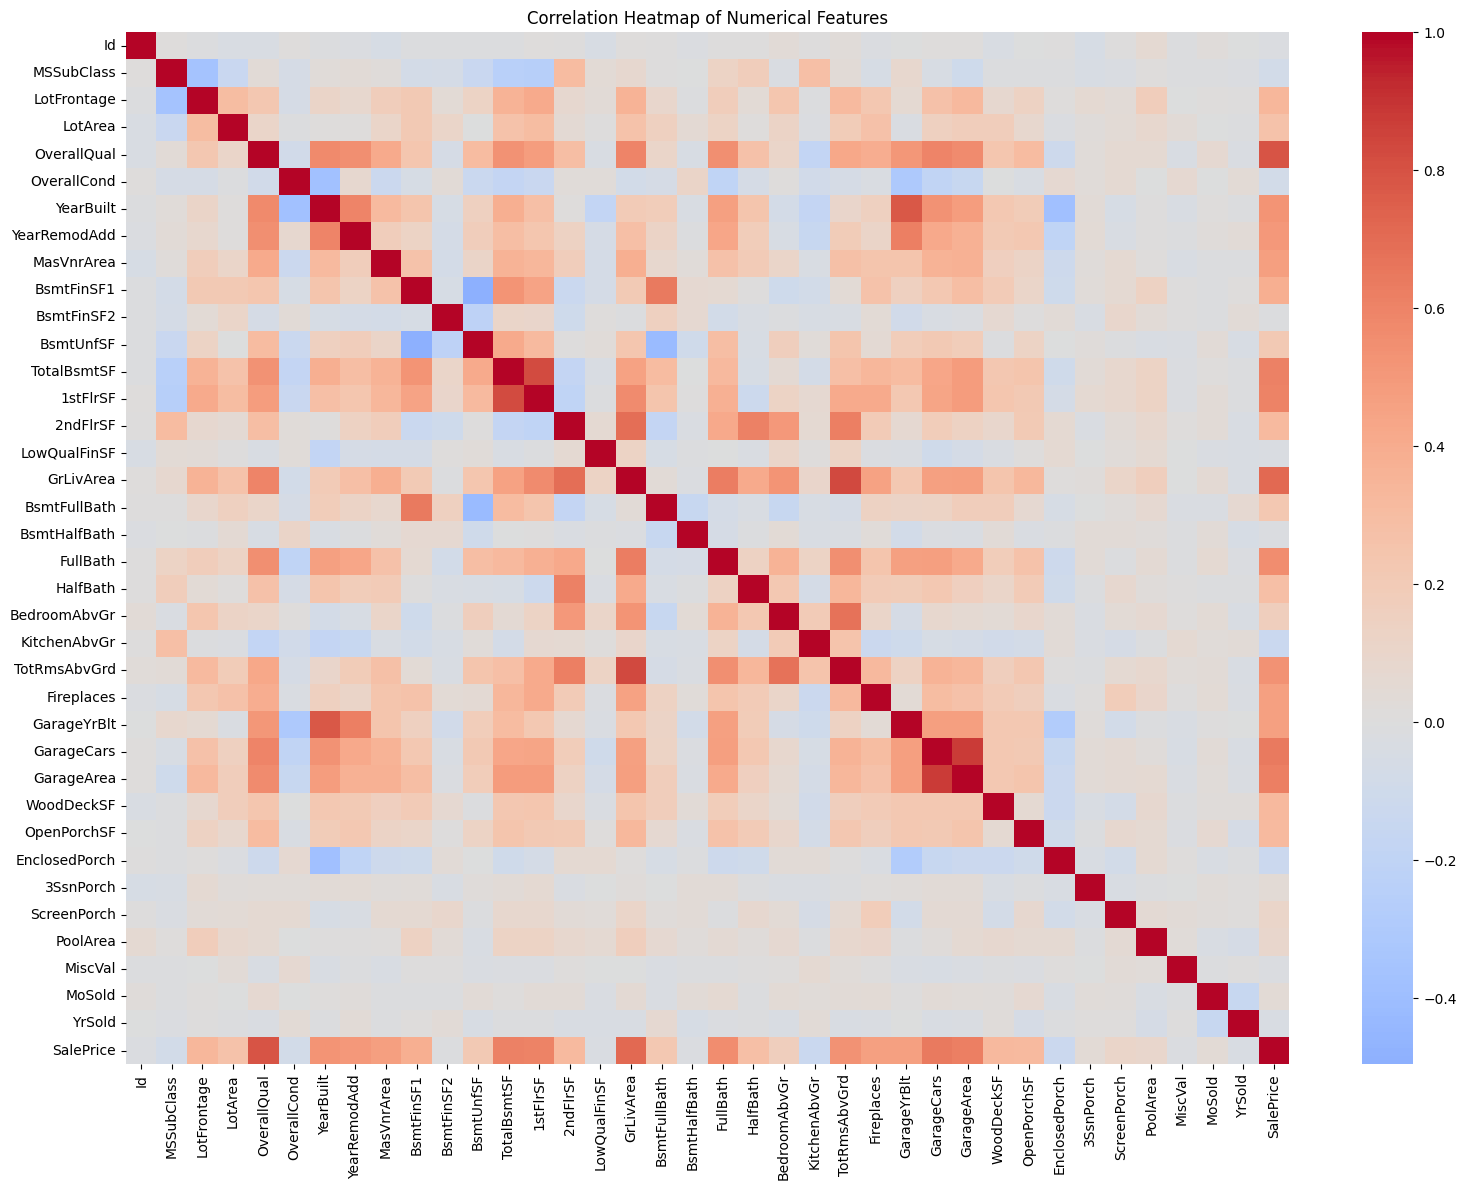

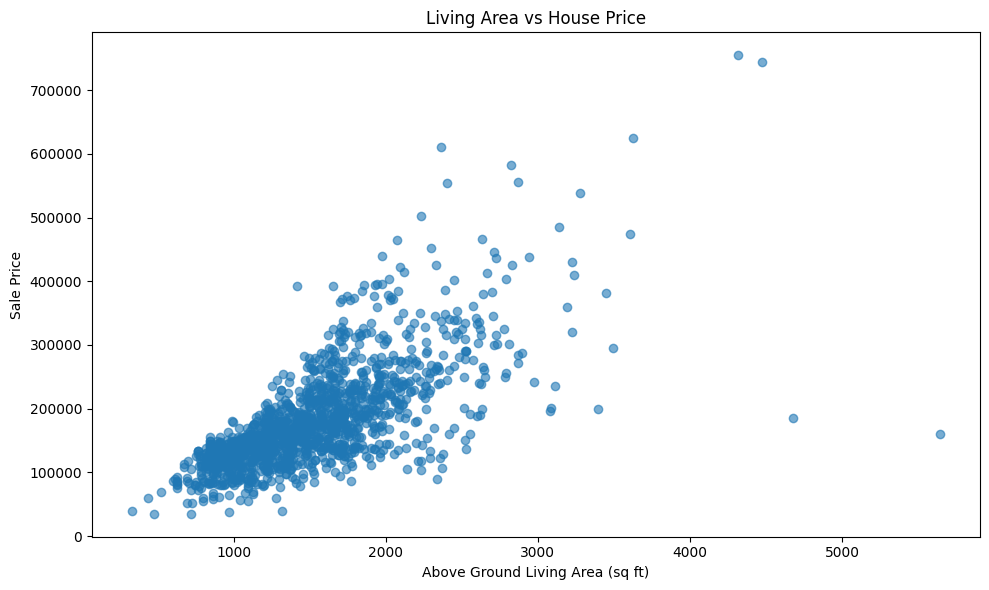

In [56]:
correlation = df_clean.select_dtypes(include=np.number).corr()

plt.figure(figsize=(16, 12))

sns.heatmap(
    correlation,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap of Numerical Features")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))

plt.scatter(
    df_clean["GrLivArea"],
    df_clean["SalePrice"],
    alpha=0.6
)

plt.title("Living Area vs House Price")
plt.xlabel("Above Ground Living Area (sq ft)")
plt.ylabel("Sale Price")

plt.tight_layout()
plt.show()

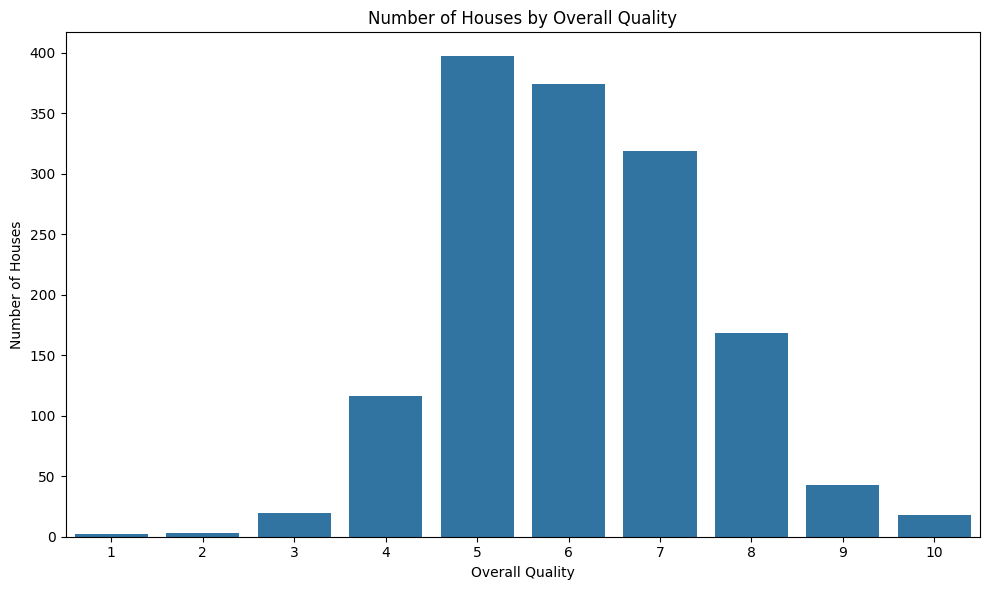

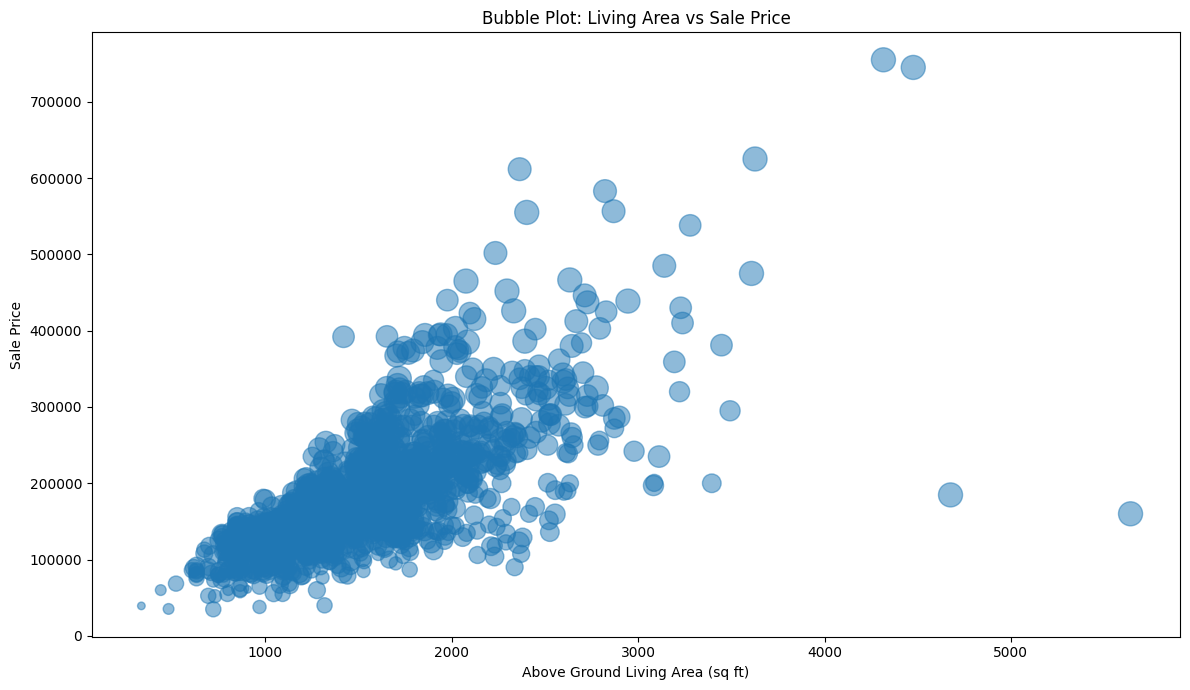

Top 10 features positively correlated with SalePrice:
SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
Name: SalePrice, dtype: float64


In [57]:
plt.figure(figsize=(10, 6))

sns.countplot(
    data=df_clean,
    x="OverallQual"
)

plt.title("Number of Houses by Overall Quality")
plt.xlabel("Overall Quality")
plt.ylabel("Number of Houses")

plt.tight_layout()
plt.show()
plt.figure(figsize=(12, 7))

plt.scatter(
    df_clean["GrLivArea"],
    df_clean["SalePrice"],
    s=df_clean["OverallQual"] * 30,
    alpha=0.5
)

plt.title("Bubble Plot: Living Area vs Sale Price")
plt.xlabel("Above Ground Living Area (sq ft)")
plt.ylabel("Sale Price")

plt.tight_layout()
plt.show()
price_correlation = (
    df_clean.select_dtypes(include=np.number)
    .corr()["SalePrice"]
    .sort_values(ascending=False)
)

print("Top 10 features positively correlated with SalePrice:")
print(price_correlation.head(11))

In [58]:
print("Features with the strongest negative correlation with SalePrice:")
print(price_correlation.tail(10))

Features with the strongest negative correlation with SalePrice:
BsmtFinSF2      -0.011378
BsmtHalfBath    -0.016844
MiscVal         -0.021190
Id              -0.021917
LowQualFinSF    -0.025606
YrSold          -0.028923
OverallCond     -0.077856
MSSubClass      -0.084284
EnclosedPorch   -0.128578
KitchenAbvGr    -0.135907
Name: SalePrice, dtype: float64


In [59]:
ml_data = df_clean.drop(columns=["Id"])

X = ml_data.drop(columns=["SalePrice"])
y = ml_data["SalePrice"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

X_encoded = pd.get_dummies(X, drop_first=True)

print("Original number of features:", X.shape[1])
print("Features after encoding:", X_encoded.shape[1])

Features shape: (1460, 79)
Target shape: (1460,)
Original number of features: 79
Features after encoding: 260


In [60]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.20,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (1168, 260)
Testing data: (292, 260)


In [61]:
X_train = X_train.fillna(X_train.median())
X_test = X_test.fillna(X_train.median())

print("Missing values in training data:", X_train.isnull().sum().sum())
print("Missing values in testing data:", X_test.isnull().sum().sum())

linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

linear_predictions = linear_model.predict(X_test)

linear_mae = mean_absolute_error(y_test, linear_predictions)
linear_rmse = np.sqrt(mean_squared_error(y_test, linear_predictions))
linear_r2 = r2_score(y_test, linear_predictions)

print("Linear Regression Results")
print("-------------------------")
print("MAE :", linear_mae)
print("RMSE:", linear_rmse)
print("R²  :", linear_r2)

decision_tree = DecisionTreeRegressor(
    random_state=42
)

decision_tree.fit(X_train, y_train)

dt_predictions = decision_tree.predict(X_test)

dt_mae = mean_absolute_error(y_test, dt_predictions)
dt_rmse = np.sqrt(mean_squared_error(y_test, dt_predictions))
dt_r2 = r2_score(y_test, dt_predictions)

print("Decision Tree Results")
print("---------------------")
print("MAE :", dt_mae)
print("RMSE:", dt_rmse)
print("R²  :", dt_r2)

Missing values in training data: 0
Missing values in testing data: 0
Linear Regression Results
-------------------------
MAE : 23929.449599134525
RMSE: 83088.76738234232
R²  : 0.09994137424713956
Decision Tree Results
---------------------
MAE : 28860.092465753423
RMSE: 44045.925811347945
R²  : 0.7470715679913407


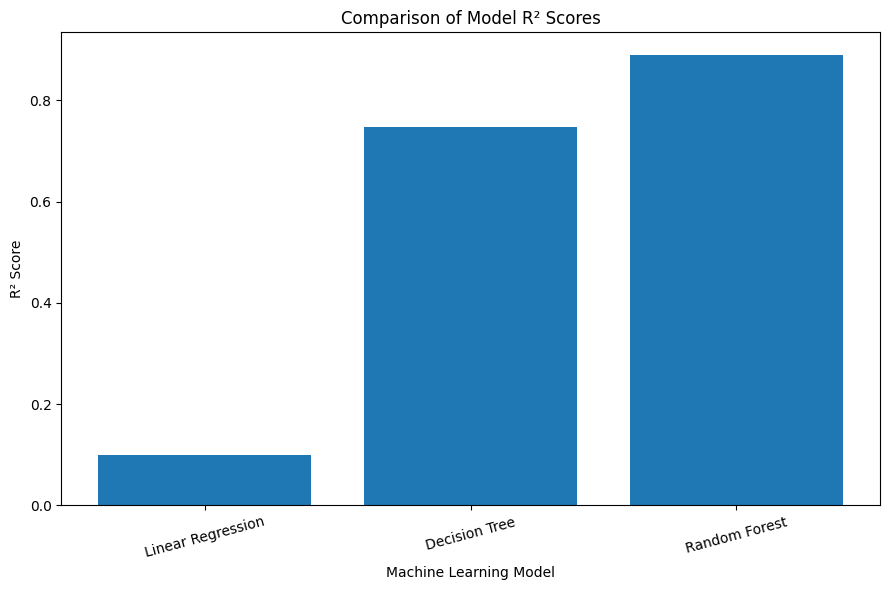

In [63]:
model_results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "MAE": [
        linear_mae,
        dt_mae,
        rf_mae
    ],
    "RMSE": [
        linear_rmse,
        dt_rmse,
        rf_rmse
    ],
    "R2 Score": [
        linear_r2,
        dt_r2,
        rf_r2
    ]
})

model_results


plt.figure(figsize=(9, 6))

plt.bar(
    model_results["Model"],
    model_results["R2 Score"]
)

plt.title("Comparison of Model R² Scores")
plt.xlabel("Machine Learning Model")
plt.ylabel("R² Score")
plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

Random Forest Results
---------------------
MAE : 17608.80385273973
RMSE: 29025.57561875442
R²  : 0.8901632059389313


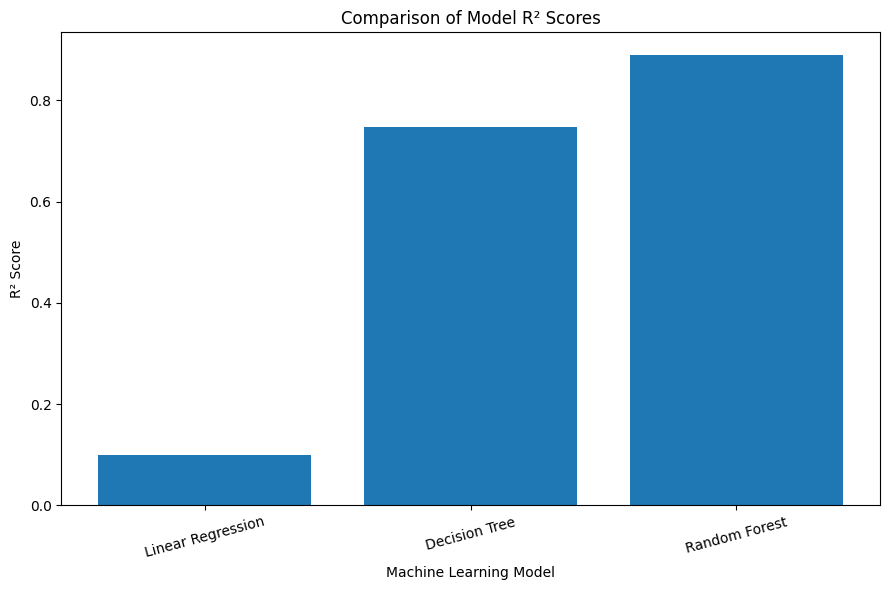

In [64]:
random_forest = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

random_forest.fit(X_train, y_train)

rf_predictions = random_forest.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_predictions)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_predictions))
rf_r2 = r2_score(y_test, rf_predictions)

print("Random Forest Results")
print("---------------------")
print("MAE :", rf_mae)
print("RMSE:", rf_rmse)
print("R²  :", rf_r2)

plt.figure(figsize=(9, 6))

plt.bar(
    model_results["Model"],
    model_results["R2 Score"]
)

plt.title("Comparison of Model R² Scores")
plt.xlabel("Machine Learning Model")
plt.ylabel("R² Score")
plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

In [65]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": random_forest.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
3,OverallQual,0.558768
15,GrLivArea,0.123191
11,TotalBsmtSF,0.034052
13,2ndFlrSF,0.030191
12,1stFlrSF,0.028542
8,BsmtFinSF1,0.028275
2,LotArea,0.017934
26,GarageArea,0.015396
25,GarageCars,0.015157
5,YearBuilt,0.013119


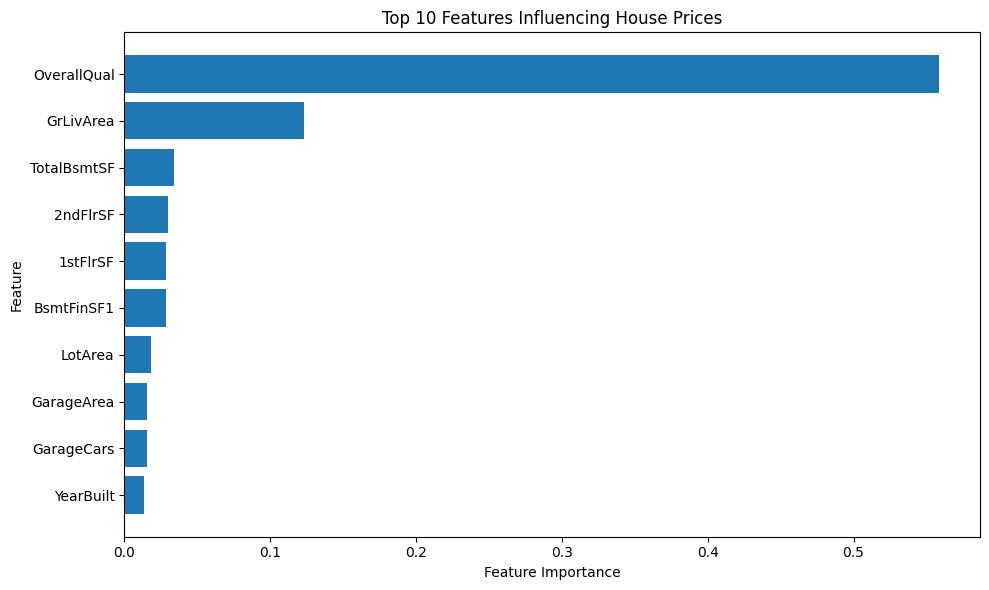

In [66]:
top_features = feature_importance.head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["Feature"][::-1],
    top_features["Importance"][::-1]
)

plt.title("Top 10 Features Influencing House Prices")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

In [67]:
sample_house = X_test.iloc[[0]]

predicted_price = random_forest.predict(sample_house)[0]
actual_price = y_test.iloc[0]

print("Actual House Price: $", round(actual_price, 2))
print("Predicted House Price: $", round(predicted_price, 2))

prediction_error = abs(actual_price - predicted_price)

print("Actual Price:    $", round(actual_price, 2))
print("Predicted Price: $", round(predicted_price, 2))
print("Prediction Error: $", round(prediction_error, 2))

comparison = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": rf_predictions
})

comparison = comparison.reset_index(drop=True)

comparison.head(10)

Actual House Price: $ 154500
Predicted House Price: $ 141154.0
Actual Price:    $ 154500
Predicted Price: $ 141154.0
Prediction Error: $ 13346.0


,Actual Price,Predicted Price
0,154500,141154.000
1,325000,316988.630
2,115000,117544.250
3,159000,151570.570
4,315500,329165.930
5,75500,84863.000
6,311500,211217.505
7,146000,151033.725
8,84500,85372.330
9,135500,130112.120


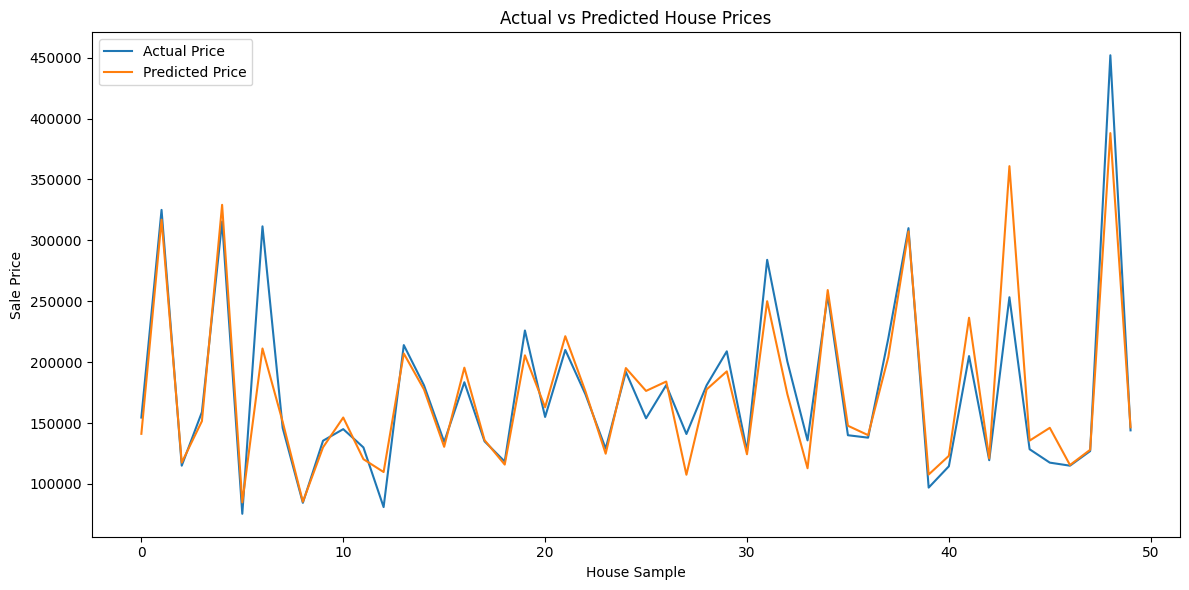

In [69]:
comparison = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": rf_predictions
})

comparison = comparison.reset_index(drop=True)

comparison.head(10)

plt.figure(figsize=(12, 6))

plt.plot(
    comparison["Actual Price"].values[:50],
    label="Actual Price"
)

plt.plot(
    comparison["Predicted Price"].values[:50],
    label="Predicted Price"
)

plt.title("Actual vs Predicted House Prices")
plt.xlabel("House Sample")
plt.ylabel("Sale Price")
plt.legend()

plt.tight_layout()
plt.show()



In [71]:
best_model_row = model_results.loc[
    model_results["R2 Score"].idxmax()
]

print("Best model:", best_model_row["Model"])
print("Best R² Score:", best_model_row["R2 Score"])

print("========== PROJECT INSIGHTS ==========\n")

print("1. The dataset contains", df_clean.shape[0], "houses.")

print("2. The dataset contains",
      df_clean.shape[1] - 1,
      "predictive features excluding the ID column.")

print("3. The best-performing model is:",
      best_model_row["Model"])

print("4. Best R² Score:",
      round(best_model_row["R2 Score"], 4))

print("5. Top 5 important features:")

for i, feature in enumerate(
    feature_importance.head(5)["Feature"],
    start=1
):
    print(f"   {i}. {feature}")

Best model: Random Forest
Best R² Score: 0.8901632059389313
========== PROJECT INSIGHTS ==========

1. The dataset contains 1460 houses.
2. The dataset contains 80 predictive features excluding the ID column.
3. The best-performing model is: Random Forest
4. Best R² Score: 0.8902
5. Top 5 important features:
   1. OverallQual
   2. GrLivArea
   3. TotalBsmtSF
   4. 2ndFlrSF
   5. 1stFlrSF


In [72]:
print("========== PROJECT INSIGHTS ==========\n")

print("1. The dataset contains", df_clean.shape[0], "houses.")

print("2. The dataset contains",
      df_clean.shape[1] - 1,
      "predictive features excluding the ID column.")

print("3. The best-performing model is:",
      best_model_row["Model"])

print("4. Best R² Score:",
      round(best_model_row["R2 Score"], 4))

print("5. Top 5 important features:")

for i, feature in enumerate(
    feature_importance.head(5)["Feature"],
    start=1
):
    print(f"   {i}. {feature}")

========== PROJECT INSIGHTS ==========

1. The dataset contains 1460 houses.
2. The dataset contains 80 predictive features excluding the ID column.
3. The best-performing model is: Random Forest
4. Best R² Score: 0.8902
5. Top 5 important features:
   1. OverallQual
   2. GrLivArea
   3. TotalBsmtSF
   4. 2ndFlrSF
   5. 1stFlrSF


# Conclusion

This project analyzed the Ames Housing dataset using data analytics,
exploratory data analysis, visualization, and machine learning techniques.

The dataset was cleaned by handling missing values, removing duplicate
records, and converting categorical variables into numerical representations.

Various visualizations were used to understand the distribution of house
prices and the relationships between different property characteristics
and house prices.

Three machine learning models were developed:

- Linear Regression
- Decision Tree Regressor
- Random Forest Regressor

The models were evaluated using Mean Absolute Error (MAE), Root Mean
Squared Error (RMSE), and R² Score. The best-performing model was selected
based on its R² Score.

Feature importance analysis was also performed to identify the major factors
that contribute to house price prediction.

Overall, this project demonstrates how data analytics and artificial
intelligence can be combined to analyze real-world housing data and build
a machine learning solution for house price prediction.